In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('Polynomial.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Senior Consultant,2,50000
2,Junior Consultant,3,50000
3,Manager,4,60000
4,Country Manager,5,80000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-Level,9,500000
9,CEO,10,1000000


In [2]:
x = df.iloc[:, 1].values
y = df.iloc[:, 2].values
x = x.reshape(-1, 1)
x

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

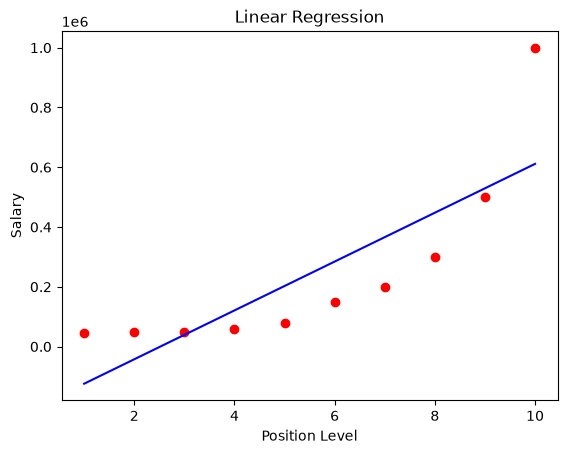

Linear Regression RMSE: 165998.90470613464


In [3]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x, y)
plt.scatter(x, y, color = 'red')
plt.plot(x, lin_reg.predict(x), color = 'blue')
plt.title("Linear Regression")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()
y_pred = lin_reg.predict(x)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("Linear Regression RMSE:", rmse)

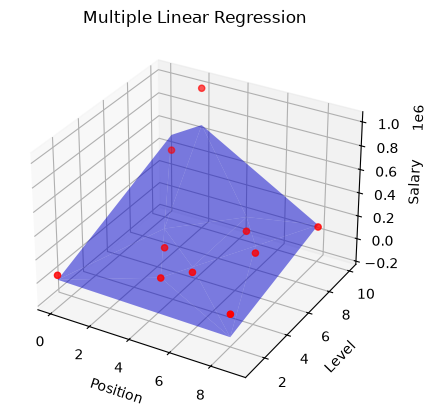

Multiple Linear Regression RMSE: 143264.83862992327


In [4]:

le_position = LabelEncoder()
df["Position"] = le_position.fit_transform(df["Position"])
X = df[["Position", "Level"]].values
Y1 = df["Salary"].values
model = LinearRegression()
model.fit(X, Y1)
y_pred = model.predict(X)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], Y1, color='red')
ax.plot_trisurf(X[:, 0], X[:, 1], y_pred, alpha=0.5, color='blue')
ax.set_title("Multiple Linear Regression")
ax.set_xlabel("Position")
ax.set_ylabel("Level")
ax.set_zlabel("Salary")
plt.show()
rmse = np.sqrt(mean_squared_error(Y1, y_pred))
print("Multiple Linear Regression RMSE:", rmse)

In [5]:
def polynomial_regression(degree):
    poly_reg = PolynomialFeatures(degree = degree)
    x_poly = poly_reg.fit_transform(x)
    print("Actual x values: ", x)
    print("After applying polyomial with degree ", degree, " : ", x_poly)
    lin_reg2 = LinearRegression()
    lin_reg2.fit(x_poly, y)
    plt.scatter(x, y, color = 'red')
    plt.plot(x, lin_reg2.predict(poly_reg.fit_transform(x)), color = 'blue')
    plt.title(f"Polynomial Regression with degree {degree}")
    plt.xlabel("Position Level")
    plt.ylabel("Salary")
    plt.show()
    y_pred = lin_reg2.predict(x_poly)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    print(f"Polynomial Regression (Degree {degree}) RMSE:", rmse)

Actual x values:  [[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
After applying polyomial with degree  2  :  [[  1.   1.   1.]
 [  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]


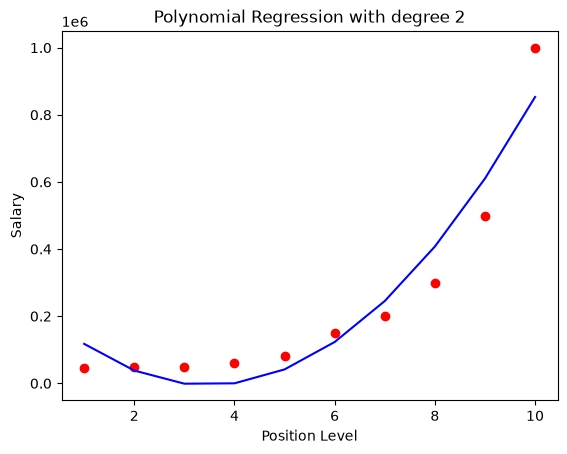

Polynomial Regression (Degree 2) RMSE: 78194.78398476614


In [6]:
polynomial_regression(2)

Actual x values:  [[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
After applying polyomial with degree  3  :  [[   1.    1.    1.    1.]
 [   1.    2.    4.    8.]
 [   1.    3.    9.   27.]
 [   1.    4.   16.   64.]
 [   1.    5.   25.  125.]
 [   1.    6.   36.  216.]
 [   1.    7.   49.  343.]
 [   1.    8.   64.  512.]
 [   1.    9.   81.  729.]
 [   1.   10.  100. 1000.]]


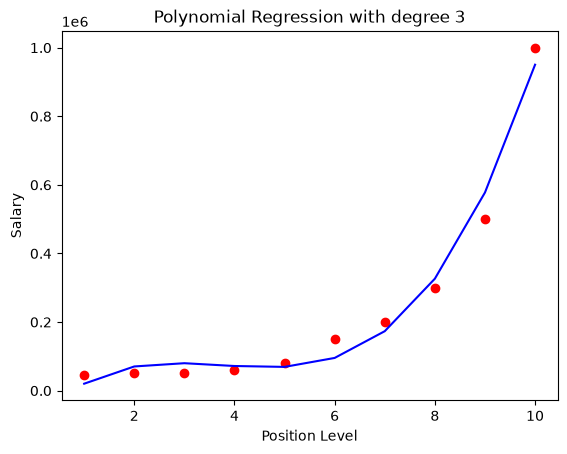

Polynomial Regression (Degree 3) RMSE: 38835.496703348595


In [7]:
polynomial_regression(3)